# EDA On Movies Dataset

Null Values

Univariate And Multivariate

Feature engineering

Outliers

In [3]:
import pandas as pd
df=pd.read_csv(r"C:\Users\welcome\Downloads\netflix_movies_detailed_up_to_2025.csv")


In [4]:
df.sample(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
2043,87827,Movie,Life of Pi,Ang Lee,"Suraj Sharma, Irrfan Khan, Ayush Tandon, Gauta...","India, Taiwan, United Kingdom, United States o...",2012-11-20,2012,7.400,NaN,"Adventure, Drama",en,"The story of an Indian boy named Pi, a zookeep...",39.406,13168,7.400,120000000,609016565
556,53840,Movie,Sharm El Sheikh: Un estate indimenticabile,Ugo Fabrizio Giordani,"Giorgio Panariello, Enrico Brignano, Maurizio ...",Italy,2010-09-17,2010,5.000,NaN,Comedy,it,"An insurance agent, in order to save his job, ...",7.017,127,5.000,0,4427419
12988,864959,Movie,The Curse of Bridge Hollow,Jeff Wadlow,"Marlon Wayans, Priah Ferguson, Kelly Rowland, ...",United States of America,2022-10-14,2022,6.500,NaN,"Adventure, Comedy, Horror, Family",en,A Halloween-hating dad reluctantly teams up wi...,7.519,464,6.500,0,0
11708,642732,Movie,Roadrunner: A Film About Anthony Bourdain,Morgan Neville,"Anthony Bourdain, Nancy Bourdain, Joel Rose, K...",United States of America,2021-07-16,2021,6.900,NaN,Documentary,en,"An intimate, behind-the-scenes look at how an ...",9.050,77,6.900,0,3701480
1004,50619,Movie,The Twilight Saga: Breaking Dawn - Part 1,Bill Condon,"Kristen Stewart, Robert Pattinson, Taylor Laut...",United States of America,2011-11-16,2011,6.196,NaN,"Adventure, Fantasy, Romance",en,The new found married bliss of Bella Swan and ...,89.456,8840,6.196,110000000,712171856


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16000 non-null  int64  
 1   type          16000 non-null  object 
 2   title         16000 non-null  object 
 3   director      15868 non-null  object 
 4   cast          15796 non-null  object 
 5   country       15534 non-null  object 
 6   date_added    16000 non-null  object 
 7   release_year  16000 non-null  int64  
 8   rating        16000 non-null  float64
 9   duration      0 non-null      float64
 10  genres        15893 non-null  object 
 11  language      16000 non-null  object 
 12  description   15868 non-null  object 
 13  popularity    16000 non-null  float64
 14  vote_count    16000 non-null  int64  
 15  vote_average  16000 non-null  float64
 16  budget        16000 non-null  int64  
 17  revenue       16000 non-null  int64  
dtypes: float64(4), int64(5), o

In [6]:
df.columns.values

array(['show_id', 'type', 'title', 'director', 'cast', 'country',
       'date_added', 'release_year', 'rating', 'duration', 'genres',
       'language', 'description', 'popularity', 'vote_count',
       'vote_average', 'budget', 'revenue'], dtype=object)

Categorical cols

show_id,type,title,director,cast,country,date_added,genres,language,description,

Numerical cols

show_id,release_year,rating,popularity,vote_count,vote_average,budget,revenue

Mixed

duration

In [7]:
df.isnull().sum()

show_id             0
type                0
title               0
director          132
cast              204
country           466
date_added          0
release_year        0
rating              0
duration        16000
genres            107
language            0
description       132
popularity          0
vote_count          0
vote_average        0
budget              0
revenue             0
dtype: int64

# Dealing with Null Values

In [8]:

df['director'].fillna(df.groupby('title')['director'].ffill().bfill(), inplace=True)


C:\Users\welcome\AppData\Local\Temp\ipykernel_18348\3655999784.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna(df.groupby('title')['director'].ffill().bfill(), inplace=True)


In [9]:
df['cast'].fillna('Unknown',inplace=True)

C:\Users\welcome\AppData\Local\Temp\ipykernel_18348\2343259098.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cast'].fillna('Unknown',inplace=True)


In [10]:
df[['genres','director']]

,genres,director
0,"Comedy, Adventure, Fantasy, Animation, Family",Mike Mitchell
1,"Action, Science Fiction, Adventure",Christopher Nolan
2,"Adventure, Fantasy",David Yates
3,"Animation, Family, Adventure","Byron Howard, Nathan Greno"
4,"Fantasy, Adventure, Animation, Family","Chris Sanders, Dean DeBlois"
...,...,...
15995,Music,Vladimir Kott
15996,Drama,Vladimir Kott
15997,Horror,"Angel Nichole Bradford, Steve Hermann"
15998,NaN,Daniel Kowal


In [11]:
import numpy as np
df['genres']=df['genres'].fillna(df.groupby('director')['genres'].
                                 transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan))


In [12]:
df[['director','genres']].isnull().sum()

director     0
genres      77
dtype: int64

In [13]:
df['genres'].fillna(df['genres'].mode().iloc[0],inplace=True)

C:\Users\welcome\AppData\Local\Temp\ipykernel_18348\832787533.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['genres'].fillna(df['genres'].mode().iloc[0],inplace=True)


In [14]:
df['genres'].isnull().sum()

np.int64(0)

In [15]:
df['country']=df['country'].fillna(df.groupby('language')['country'].
                                   transform(lambda x:x.mode().iloc[0] if not x.mode().empty else np.nan))

In [16]:
df['country'].isnull().sum()

np.int64(3)

In [17]:
df['country'].fillna(df['country'].mode().iloc[0],inplace=True)


C:\Users\welcome\AppData\Local\Temp\ipykernel_18348\870026517.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['country'].fillna(df['country'].mode().iloc[0],inplace=True)


In [18]:
df.country.unique()

array(['United States of America',
       'United Kingdom, United States of America',
       'China, Hong Kong, United States of America', ...,
       'Norway, Romania',
       'Indonesia, United Kingdom, United States of America',
       'Germany, Saudi Arabia, Qatar, France, Greece, Netherlands, United Kingdom, Palestinian Territory'],
      dtype=object)

In [19]:
df.drop(columns='duration',inplace=True)

In [20]:
df.isnull().sum()


show_id           0
type              0
title             0
director          0
cast              0
country           0
date_added        0
release_year      0
rating            0
genres            0
language          0
description     132
popularity        0
vote_count        0
vote_average      0
budget            0
revenue           0
dtype: int64

In [21]:
df['description'].fillna(df['title'],inplace=True)


C:\Users\welcome\AppData\Local\Temp\ipykernel_18348\2014481577.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['description'].fillna(df['title'],inplace=True)


In [22]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
genres          0
language        0
description     0
popularity      0
vote_count      0
vote_average    0
budget          0
revenue         0
dtype: int64

In [23]:
numeric_df=df.select_dtypes(include='number')
numeric_df.corr()

,show_id,release_year,rating,popularity,vote_count,vote_average,budget,revenue
show_id,1.000000,0.928273,-0.325255,0.096656,-0.185147,-0.325255,-0.141630,-0.114259
release_year,0.928273,1.000000,-0.230341,0.131493,-0.106090,-0.230341,-0.036975,-0.043304
rating,-0.325255,-0.230341,1.000000,0.071178,0.173600,1.000000,0.096967,0.117231
popularity,0.096656,0.131493,0.071178,1.000000,0.158254,0.071178,0.218221,0.216282
vote_count,-0.185147,-0.106090,0.173600,0.158254,1.000000,0.173600,0.666053,0.749207
vote_average,-0.325255,-0.230341,1.000000,0.071178,0.173600,1.000000,0.096967,0.117231
budget,-0.141630,-0.036975,0.096967,0.218221,0.666053,0.096967,1.000000,0.752193
revenue,-0.114259,-0.043304,0.117231,0.216282,0.749207,0.117231,0.752193,1.000000


# Univariate Analysis

In [24]:
country=df['country'].str.split(",")
country.sum()
set(country.sum())


{' Afghanistan',
 ' Argentina',
 ' Aruba',
 ' Australia',
 ' Austria',
 ' Bahamas',
 ' Belarus',
 ' Belgium',
 ' Bosnia and Herzegovina',
 ' Brazil',
 ' Bulgaria',
 ' Cambodia',
 ' Canada',
 ' Cayman Islands',
 ' Chile',
 ' China',
 ' Colombia',
 ' Congo',
 " Cote D'Ivoire",
 ' Croatia',
 ' Cuba',
 ' Cyprus',
 ' Czech Republic',
 ' Denmark',
 ' Dominican Republic',
 ' Ecuador',
 ' Egypt',
 ' Estonia',
 ' Ethiopia',
 ' Faeroe Islands',
 ' Finland',
 ' France',
 ' French Polynesia',
 ' Georgia',
 ' Germany',
 ' Ghana',
 ' Greece',
 ' Guadaloupe',
 ' Hong Kong',
 ' Hungary',
 ' Iceland',
 ' India',
 ' Indonesia',
 ' Iran',
 ' Iraq',
 ' Ireland',
 ' Israel',
 ' Italy',
 ' Japan',
 ' Jordan',
 ' Kazakhstan',
 ' Kenya',
 ' Kosovo',
 ' Latvia',
 ' Lebanon',
 ' Liechtenstein',
 ' Lithuania',
 ' Luxembourg',
 ' Macao',
 ' Macedonia',
 ' Malaysia',
 ' Malta',
 ' Mauritania',
 ' Mauritius',
 ' Mexico',
 ' Monaco',
 ' Montenegro',
 ' Morocco',
 ' Namibia',
 ' Netherlands',
 ' Netherlands Antilles'

In [25]:

import pandas as pd
df_split=df['country'].str.split(', ',expand=True).stack().reset_index(drop=True)
df_split.value_counts()


United States of America                8078
United Kingdom                          1743
France                                  1708
Canada                                  1063
Japan                                   1000
                                        ... 
Mauritania                                 1
Botswana                                   1
Kuwait                                     1
Greenland                                  1
United States Minor Outlying Islands       1
Name: count, Length: 135, dtype: int64

<Axes: xlabel='count'>

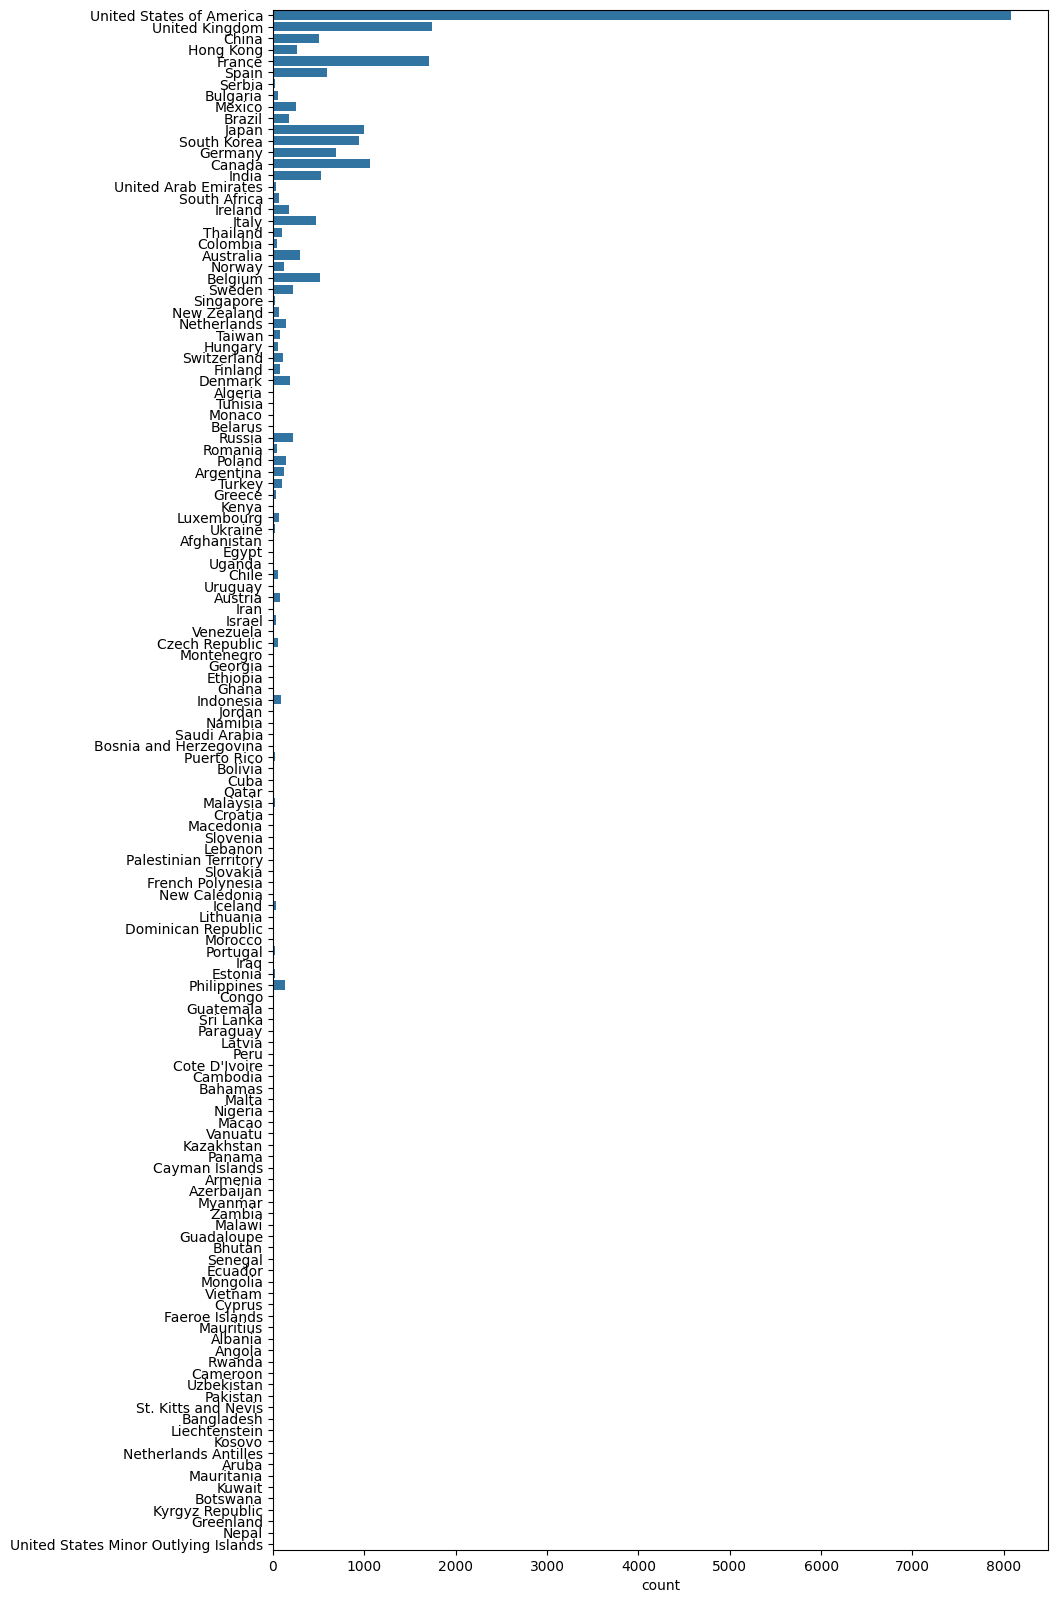

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
fig=plt.figure(figsize=(10,20))
sns.countplot(df_split)

United States of America is the country which releases most of the movies.

<Axes: xlabel='language', ylabel='count'>

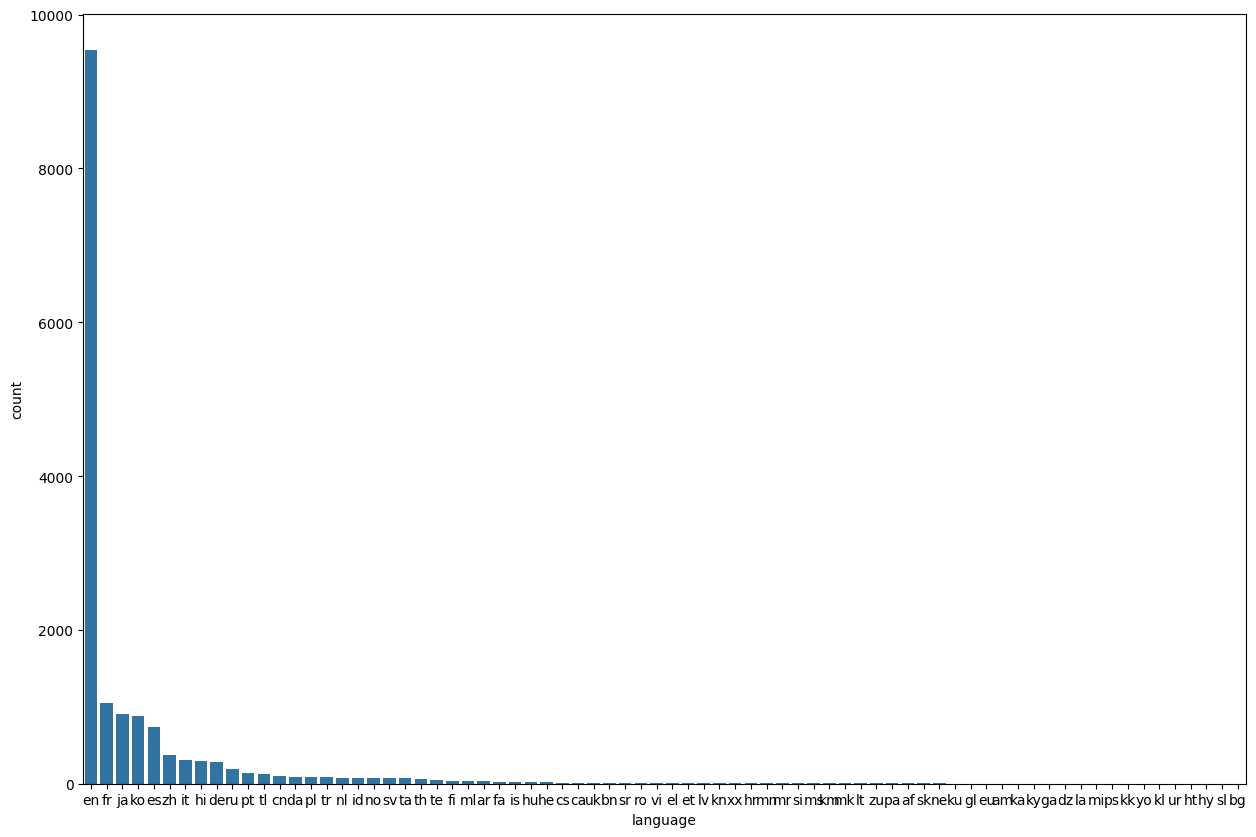

In [27]:
# Language
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))
sns.barplot(df['language'].value_counts())

<Axes: xlabel='count'>

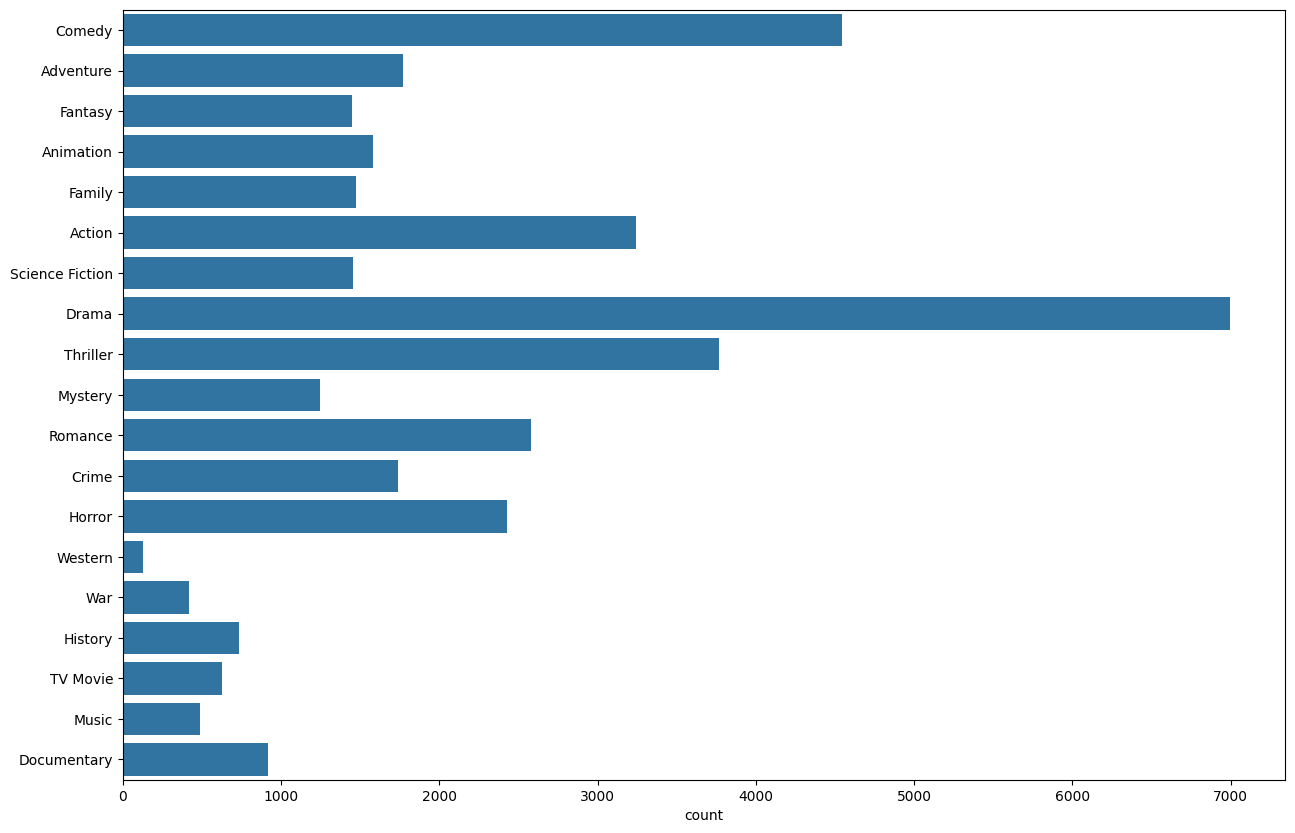

In [28]:
df_split_genre=df['genres'].str.split(', ',expand=True).stack().reset_index(drop=True)
plt.figure(figsize=(15,10))
sns.countplot(df_split_genre)

The most common genre is drama.

# Analysis on Numerical cols

<Axes: xlabel='budget', ylabel='Density'>

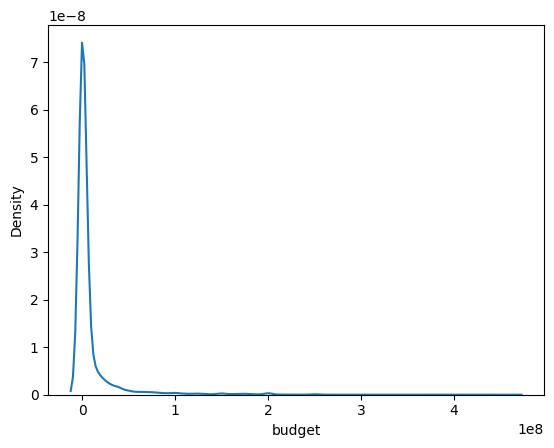

In [29]:
sns.kdeplot(df['budget'])


Most of the budegt of the movies are very low.

<Axes: xlabel='budget', ylabel='Count'>

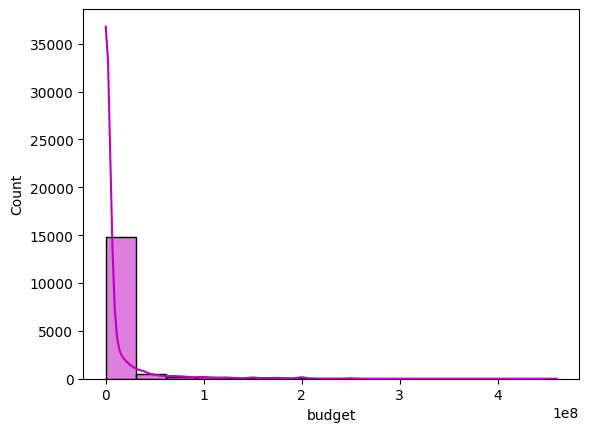

In [30]:
sns.histplot(df['budget'],bins=15,kde=True,color='m')

For finding range of something we can use histplot.

Here the budget of most of the movies lying in the range of 0 to 15000.And the big budget movies are very rare and are considered as outliers.


In [31]:
print(df['budget'].skew())
print(df['budget'].kurt())

5.744231140474282
42.73387710109045


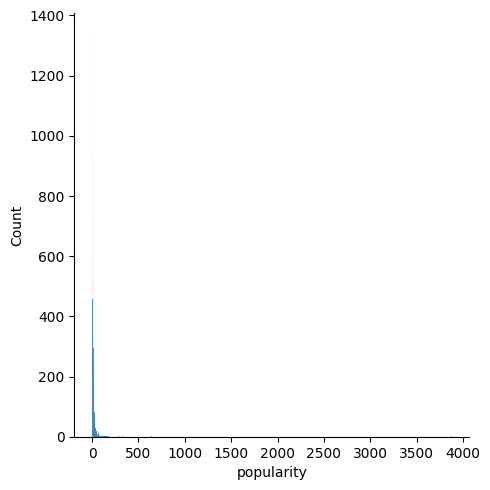

In [32]:
sns.displot(df['popularity'])

Most of the movies are really not very popular(means low popularity movies are very high in number) and we can clearly see that there are some outliers in this also , will handle it outlier section. 

In [33]:
df.loc[df['popularity'].idxmax(),['country']] 

country    United States of America
Name: 15000, dtype: object

<Axes: xlabel='rating', ylabel='Count'>

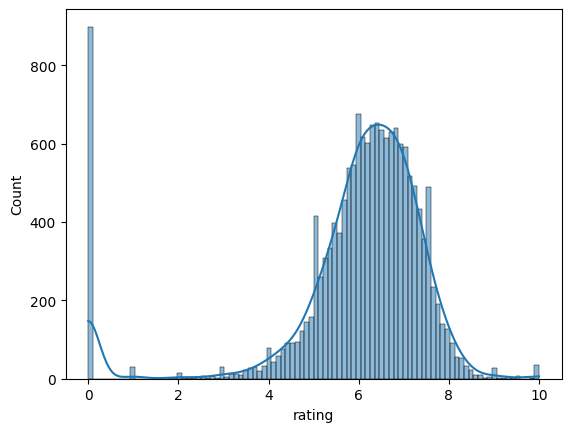

In [34]:
sns.histplot(df['rating'],kde=True)

In [35]:
print(df['rating'].kurt())
print(df['rating'].skew())


5.000980431177963
-2.1165945023982364


This graph denotes that the kurtosis value is very high more than a normal distribution(kurt=3) this indicates many outliers in it and the data is highly skewed the tail is to the left and most of the data points are having high rating (right side).

<Axes: xlabel='revenue', ylabel='Count'>

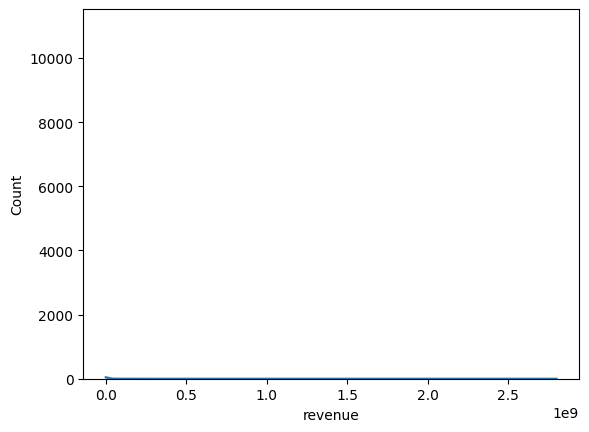

In [36]:
sns.histplot(df['revenue'],kde=True)

In [37]:
print(df['revenue'].skew())
print(df['revenue'].kurt())

9.075029493079608
115.00693233289249


**** This graph indicates that the revenue of the different movies are different , lekin kisi bhi particular type ka revenue mei bahut counts nhi hai 

# Comparison between data points

Budget Vs. Popularity

Text(0, 0.5, 'Popularity')

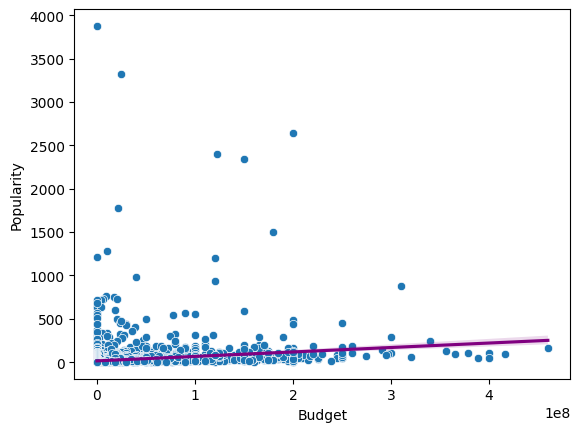

In [38]:
import matplotlib.pyplot as plt
sns.scatterplot(df,x='budget',y='popularity')
sns.regplot(df,x='budget',y='popularity',color='purple',scatter=False)
plt.xlabel('Budget')
plt.ylabel('Popularity')




1.Many of the movies have low budget so is popularity.

2.Some of the movies are having high budget but not gaining popularity as much.

3.Very few of them are having very low budget but the popularity is very high(considered as outliers).

So in all total the popularity of a movie is not very much dependable on the budget of the movie.


Revenue Vs. Popularity

20.384728062500002
24463075.657875
115.00693233289249
9.075029493079608


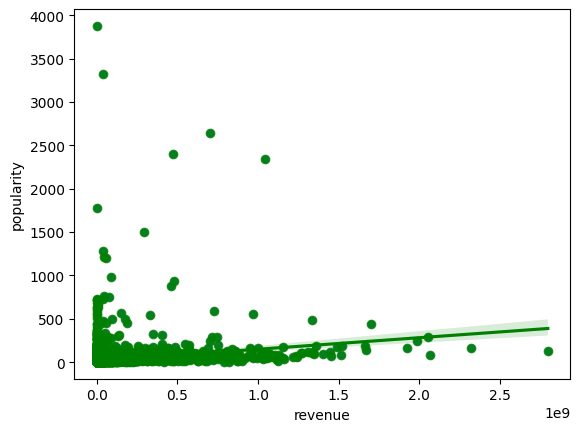

In [39]:
import matplotlib.pyplot as plt
sns.scatterplot(df,x='revenue',y='popularity')
sns.regplot(df,x='revenue',y='popularity',color='g')
# plt.axhline(y=df['popularity'].mean(),color='r',linestyle='--',label='Avg. Popularity')
# plt.axvline(x=df['revenue'].mean(),color='g',linestyle='--',label='Avg. Budget')
print(df['popularity'].mean())
print(df['revenue'].mean())
print(df['revenue'].kurt())
print(df['revenue'].skew())


This graph shows a very little positive correlation betweeen the revenue and the popularity it shows that when revenue increases the popularity of the movies is slightly increases.

Vote_Count Vs. Popularity

6.6619188096916675
60.145457474477325


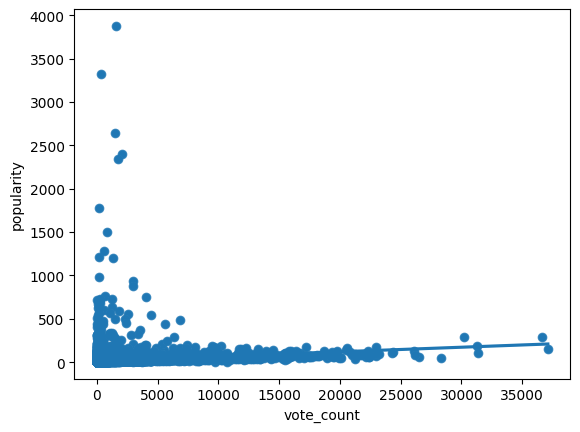

In [40]:
sns.scatterplot(df,x='vote_count',y='popularity')
sns.regplot(df,x='vote_count',y='popularity')
print(df['vote_count'].skew())
print(df['vote_count'].kurt()) 

Even vote_count is slightly effective for popularity.

-2.1165945023982364
5.000980431177963
0.15825392771548108


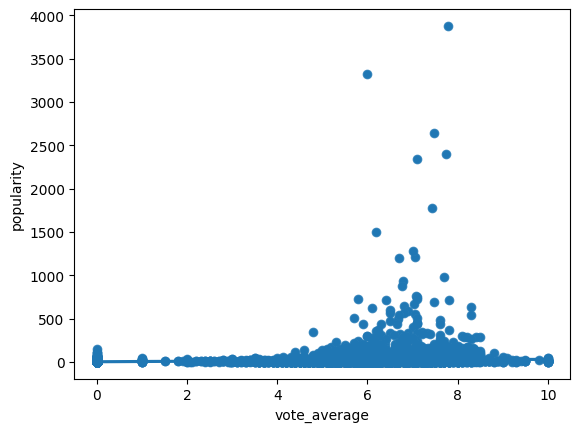

In [41]:
sns.scatterplot(df,x='vote_average',y='popularity')
sns.regplot(df,x='vote_average',y='popularity')
print(df['vote_average'].skew())
print(df['vote_average'].kurt())
print(df['popularity'].corr(df['vote_count']))

Since the regplot is indicating flat line this indicates no relationship between popularity and vote_average.But the graph is indicating that the movies with vote count greater than 4 are having some popularity and very few of them is gaining popularity very much(considered as outliers) this may be because of some external affairs that these movies are gaining popularity but there is no or very little relationship between popularity and vote_count.

# Revenue

Revenue Vs. Budget

0.7521928531927862


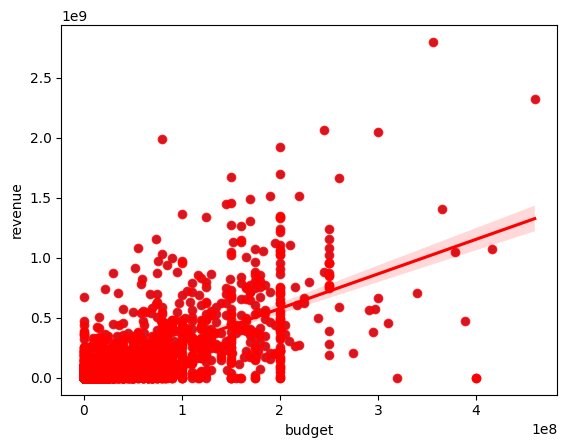

In [42]:
sns.scatterplot(df,x='budget',y='revenue') 
sns.regplot(df,x='budget',y='revenue',color='r') 
print(df['revenue'].corr(df['budget']))

Although most of the data points are having low budget and they generate low revenue also yet some of them are having high budget and generating high revenue.All in total with increase in budget ,generation of revenue also increases. But also this graph indicates some outliers means low budget movies are generating high revenues too.

Revenue Vs. Vote_Count

0.7492071976306798


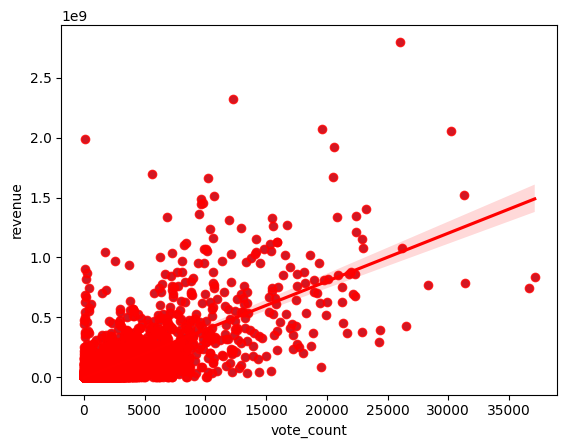

In [43]:
sns.scatterplot(df,x='vote_count',y='revenue') 
sns.regplot(df,x='vote_count',y='revenue',color='r') 
print(df['revenue'].corr(df['vote_count']))

Revenue is increasing with increase in vote_count.And its obvious that when a vote_count of a movie is increasing its revenue is also increasing.The confidence interval get widens as the vote_count increases ,it becomes less precise for higher vote_count as the data points are not much in number.

In [44]:
df.columns.values

array(['show_id', 'type', 'title', 'director', 'cast', 'country',
       'date_added', 'release_year', 'rating', 'genres', 'language',
       'description', 'popularity', 'vote_count', 'vote_average',
       'budget', 'revenue'], dtype=object)

vote_count & vote_average

<Axes: xlabel='vote_average', ylabel='vote_count'>

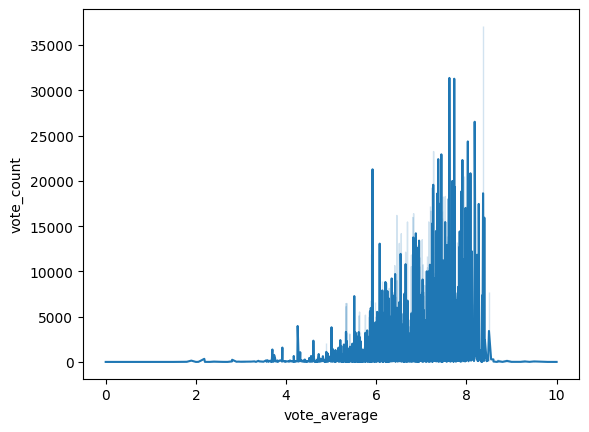

In [45]:
sns.lineplot(df,x='vote_average',y='vote_count')

# Feature Engineering

drop the columns which is not needed.

In [46]:

df1=df.drop(columns=['show_id','release_year','cast','director','date_added','type','description'])
df1.sample(10)

,title,country,rating,genres,language,popularity,vote_count,vote_average,budget,revenue
10080,All the Bright Places,United States of America,7.600,"Romance, Drama",en,23.404,2895,7.600,0,0
6577,Swapping: My Friend's Wife,South Korea,4.000,"Romance, Drama",ko,9.457,2,4.000,0,0
15889,Art Attack! The Dissection of Terrifier 3,United States of America,0.000,Documentary,en,5.463,0,0.000,0,0
10301,Aunt's Temptation 3,South Korea,7.118,Romance,ko,13.474,17,7.118,0,0
13274,Wingwomen,France,6.100,"Action, Comedy, Drama",fr,24.064,446,6.100,0,0
15561,Doggies,Ukraine,0.000,Comedy,uk,7.864,0,0.000,0,0
2245,A Royal Affair,"Czech Republic, Denmark, Germany, Sweden",7.400,"Drama, History, Romance",da,13.691,881,7.400,8000000,14800000
1686,Whatsoeverly,Italy,6.000,Comedy,it,6.230,528,6.000,0,0
3637,Absolute Deception,United States of America,4.700,Action,en,7.640,74,4.700,5000000,0
15258,Spit,Australia,0.000,"Comedy, Crime",en,13.932,0,0.000,0,0


In [47]:
df1['profit']=df1['revenue']-df1['budget']
df1.sample(10)

,title,country,rating,genres,language,popularity,vote_count,vote_average,budget,revenue,profit
8830,Thomas & Friends: Big World! Big Adventures! T...,"United Kingdom, United States of America",7.200,"Family, Animation, Adventure",en,7.991,37,7.200,0,0,0
5660,Tamasha,India,6.757,"Romance, Drama, Comedy",hi,8.133,150,6.757,0,0,0
7244,God of War,"China, Hong Kong",6.200,"Action, History",zh,16.006,88,6.200,25000000,0,-25000000
3158,Ruby Red,Germany,7.000,"Fantasy, Drama, Romance",de,18.767,1116,7.000,0,5524381,5524381
10029,Peninsula,South Korea,6.751,"Horror, Action, Thriller, Adventure",ko,38.164,2389,6.751,17000000,42698327,25698327
9832,Condition of a Mom: Sugar Mom,South Korea,0.000,"Drama, Romance",ko,7.983,0,0.000,0,0,0
12117,The Unbearable Weight of Massive Talent,United States of America,6.800,"Action, Comedy, Crime",en,30.964,2089,6.800,30000000,29116320,-883680
15465,Wheel Gone Kid 4,United Kingdom,0.000,Comedy,en,8.932,0,0.000,10000,0,-10000
11166,The Stronghold,France,7.400,"Thriller, Action, Crime",fr,21.488,1309,7.400,14479740,0,-14479740
9852,A Violent Separation,United States of America,7.100,"Crime, Thriller",en,7.857,87,7.100,0,0,0


Which movie is giving the highest profit with profit

In [48]:
high_profit_movie=df1.loc[df1['profit'].idxmax(),'title']
high_profit_movie 

'Avengers: Endgame'

Handling outliers

In [49]:
# Handling outliers in budget

import numpy as np

b_mean=df1['budget'].mean()
b_std=df1['budget'].std()

q1=np.percentile(df1['budget'],25)
q3=np.percentile(df1['budget'],75)

lower_bound=q1-1.5*(q3-q1)
upper_bound=q3+1.5*(q3-q1)

df1=df1[(df1['budget']>lower_bound)&(df1['budget']<upper_bound)]

df1


,title,country,rating,genres,language,popularity,vote_count,vote_average,budget,revenue,profit
9,Room in Rome,"France, Spain",6.416,"Drama, Romance",es,90.230,748,6.416,0,844281,844281
14,A Serbian Film,Serbia,5.471,"Crime, Horror, Thriller",sr,74.238,2018,5.471,0,0,0
15,Undisputed III: Redemption,United States of America,7.517,"Action, Thriller, Crime, Drama",en,71.837,925,7.517,3000000,282548,-2717452
17,Three Steps Above Heaven,Spain,7.700,"Romance, Drama",es,66.968,3095,7.700,0,0,0
28,El Infierno,Mexico,7.900,"Action, Crime, Western, Comedy, Drama",es,43.812,691,7.900,0,6703873,6703873
...,...,...,...,...,...,...,...,...,...,...,...
15995,Festival de Viña del Mar 2025: Ha*Ash,Chile,0.000,Music,es,4.931,0,0.000,0,0,0
15996,Man and Woman,Russia,0.000,Drama,ru,4.930,0,0.000,0,0,0
15997,Night of the Dead Sorority Babes,United States of America,1.000,Horror,en,4.922,1,1.000,0,0,0
15998,A Dunces Burden,United States of America,0.000,Drama,en,4.921,0,0.000,0,0,0


In [50]:
# Rating

r_mean=df1['rating'].mean()
r_std=df1['rating'].std()

q1=np.percentile(df1['rating'],25)
q3=np.percentile(df1['rating'],75)

lower_bound=q1-1.5*(q3-q1)
upper_bound=q3+1.5*(q3-q1)

df1=df1[(df1['rating']>lower_bound)&(df1['rating']<upper_bound)]

df1 

,title,country,rating,genres,language,popularity,vote_count,vote_average,budget,revenue,profit
9,Room in Rome,"France, Spain",6.416,"Drama, Romance",es,90.230,748,6.416,0,844281,844281
14,A Serbian Film,Serbia,5.471,"Crime, Horror, Thriller",sr,74.238,2018,5.471,0,0,0
15,Undisputed III: Redemption,United States of America,7.517,"Action, Thriller, Crime, Drama",en,71.837,925,7.517,3000000,282548,-2717452
17,Three Steps Above Heaven,Spain,7.700,"Romance, Drama",es,66.968,3095,7.700,0,0,0
28,El Infierno,Mexico,7.900,"Action, Crime, Western, Comedy, Drama",es,43.812,691,7.900,0,6703873,6703873
...,...,...,...,...,...,...,...,...,...,...,...
15953,Delicious,Germany,7.000,Drama,en,5.113,1,7.000,0,0,0
15960,Un an avec Jordan Bardella,France,6.800,Documentary,fr,5.090,2,6.800,0,0,0
15964,Slide,United States of America,7.500,"Drama, Thriller",en,5.076,2,7.500,0,0,0
15984,Dreams,"Mexico, United States of America",7.000,"Drama, Romance",en,4.969,1,7.000,0,0,0
